In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
hybrid_df = pd.read_csv(
    r"E:\Reel-Recommendation-Engine\data\processed\hybrid_recommendations.csv"
)

interactions_df = pd.read_csv(
    r"E:\Reel-Recommendation-Engine\data\processed\interactions_cleaned.csv"
)

videos_df = pd.read_csv(
    r"E:\Reel-Recommendation-Engine\data\processed\videos_cleaned.csv"
)

print(hybrid_df.shape)
print(interactions_df.shape)
print(videos_df.shape)

(1000, 5)
(1414622, 22)
(7583, 12)


In [3]:
relevant_interactions = interactions_df[
    interactions_df["interaction_score"] > 0.5
]

print(
    "Relevant Interactions:",
    relevant_interactions.shape
)

Relevant Interactions: (736744, 22)


In [4]:
hits = 0
total_recommendations = len(hybrid_df)

for _, row in hybrid_df.iterrows():

    user_id = row["user_id"]
    video_id = row["video_id"]

    relevant = relevant_interactions[
        (relevant_interactions["user_id"] == user_id)
        &
        (relevant_interactions["video_id"] == video_id)
    ]

    if len(relevant) > 0:
        hits += 1

precision_at_10 = hits / total_recommendations

print("Hits:", hits)
print("Precision@10:", precision_at_10)

Hits: 15
Precision@10: 0.015


In [5]:
relevant_pairs = set(
    zip(
        relevant_interactions["user_id"],
        relevant_interactions["video_id"]
    )
)

recommended_pairs = set(
    zip(
        hybrid_df["user_id"],
        hybrid_df["video_id"]
    )
)

matched = len(
    relevant_pairs.intersection(
        recommended_pairs
    )
)

recall_at_10 = matched / len(relevant_pairs)

print("Recall@10:", recall_at_10)

Recall@10: 2.0386667119703715e-05


In [6]:
recommended_videos = (
    hybrid_df["video_id"]
    .nunique()
)

total_videos = (
    videos_df["video_id"]
    .nunique()
)

coverage = (
    recommended_videos /
    total_videos
)

print("Coverage:", coverage)

Coverage: 0.07503626533034419


In [7]:
avg_score = (
    hybrid_df["hybrid_score"]
    .mean()
)

print(
    "Average Hybrid Score:",
    avg_score
)

Average Hybrid Score: 0.1422081712025262


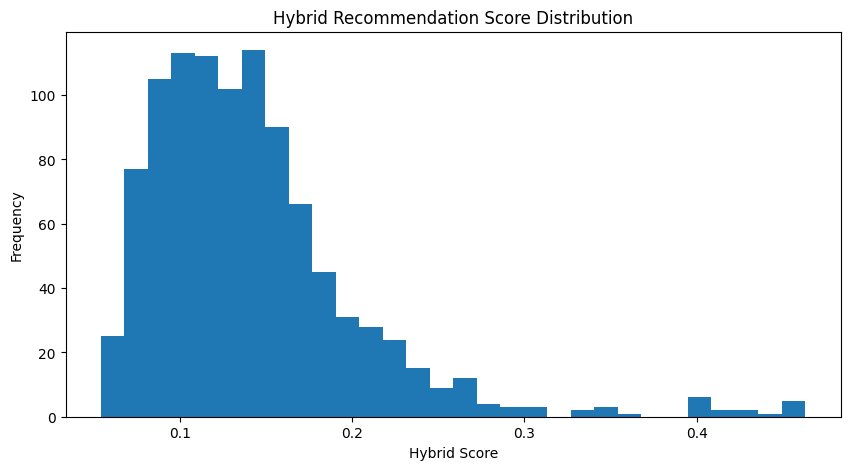

In [8]:
plt.figure(figsize=(10,5))

plt.hist(
    hybrid_df["hybrid_score"],
    bins=30
)

plt.title(
    "Hybrid Recommendation Score Distribution"
)

plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")

plt.show()

In [9]:
evaluation_report = pd.DataFrame({

    "Metric": [
        "Precision@10",
        "Recall@10",
        "Coverage",
        "Average Hybrid Score"
    ],

    "Value": [
        precision_at_10,
        recall_at_10,
        coverage,
        avg_score
    ]
})

evaluation_report

,Metric,Value
0,Precision@10,0.015000
1,Recall@10,0.000020
2,Coverage,0.075036
3,Average Hybrid Score,0.142208


In [10]:
evaluation_report.to_csv(
    r"E:\Reel-Recommendation-Engine\data\processed\evaluation_report.csv",
    index=False
)

print("Evaluation Report Saved")

Evaluation Report Saved


In [11]:
evaluation_report

,Metric,Value
0,Precision@10,0.015000
1,Recall@10,0.000020
2,Coverage,0.075036
3,Average Hybrid Score,0.142208
